In [3]:
from google.colab import files

uploaded = files.upload()


Saving molecular_dataset (1).csv to molecular_dataset (1).csv


In [4]:
import os

print(os.listdir())

['.config', 'molecular_dataset (1).csv', 'molecular_dataset.csv', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv("molecular_dataset (1).csv")

print("Dataset Shape:", df.shape)

print(df)

Dataset Shape: (20, 7)
            Name    Formula       MW    TPSA  HBD  HBA     LogP
0        Aspirin     C9H8O4  180.159   63.60    1    3  1.31010
1       Caffeine  C8H10N4O2  194.194   61.82    0    3 -1.02930
2      Ibuprofen   C13H18O2  206.285   37.30    1    1  3.07320
3    Paracetamol    C8H9NO2  151.165   49.33    2    2  1.35060
4        Benzene       C6H6   78.114    0.00    0    0  1.68660
5        Toluene       C7H8   92.141    0.00    0    0  1.99502
6         Phenol      C6H6O   94.113   20.23    1    1  1.39220
7        Acetone      C3H6O   58.080   17.07    0    1  0.59530
8        Ethanol      C2H6O   46.069   20.23    1    1 -0.00140
9       Methanol       CH4O   32.042   20.23    1    1 -0.39150
10       Glucose    C6H12O6  180.156  110.38    5    6 -3.22140
11   Acetic acid     C2H4O2   60.052   37.30    1    1  0.09090
12   Citric acid     C6H8O7  192.123  132.13    4    4 -1.24850
13      Nicotine   C10H14N2  162.236   16.13    0    2  1.84830
14   Cholesterol 

In [6]:
X = df[["MW","TPSA","HBD","HBA","LogP"]]
print(X.shape)
print(X)

(20, 5)
         MW    TPSA  HBD  HBA     LogP
0   180.159   63.60    1    3  1.31010
1   194.194   61.82    0    3 -1.02930
2   206.285   37.30    1    1  3.07320
3   151.165   49.33    2    2  1.35060
4    78.114    0.00    0    0  1.68660
5    92.141    0.00    0    0  1.99502
6    94.113   20.23    1    1  1.39220
7    58.080   17.07    0    1  0.59530
8    46.069   20.23    1    1 -0.00140
9    32.042   20.23    1    1 -0.39150
10  180.156  110.38    5    6 -3.22140
11   60.052   37.30    1    1  0.09090
12  192.123  132.13    4    4 -1.24850
13  162.236   16.13    0    2  1.84830
14  386.664   20.23    1    1  7.38870
15   60.056   69.11    2    1 -0.97620
16   93.129   26.02    1    1  1.26880
17  128.174    0.00    0    0  2.83980
18   44.053   17.07    0    1  0.20520
19   30.026   17.07    0    1 -0.18490


In [7]:
print(X.shape)

(20, 5)


In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,random_state=42)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

print(df[["Name", "Cluster"]])

            Name  Cluster
0        Aspirin        2
1       Caffeine        2
2      Ibuprofen        2
3    Paracetamol        2
4        Benzene        0
5        Toluene        0
6         Phenol        0
7        Acetone        0
8        Ethanol        0
9       Methanol        0
10       Glucose        2
11   Acetic acid        0
12   Citric acid        2
13      Nicotine        2
14   Cholesterol        1
15          Urea        0
16       Aniline        0
17   Naphthalene        0
18  Acetaldehyde        0
19  Formaldehyde        0


In [12]:
print(df["Cluster"].value_counts())

Cluster
0    12
2     7
1     1
Name: count, dtype: int64


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(20, 2)


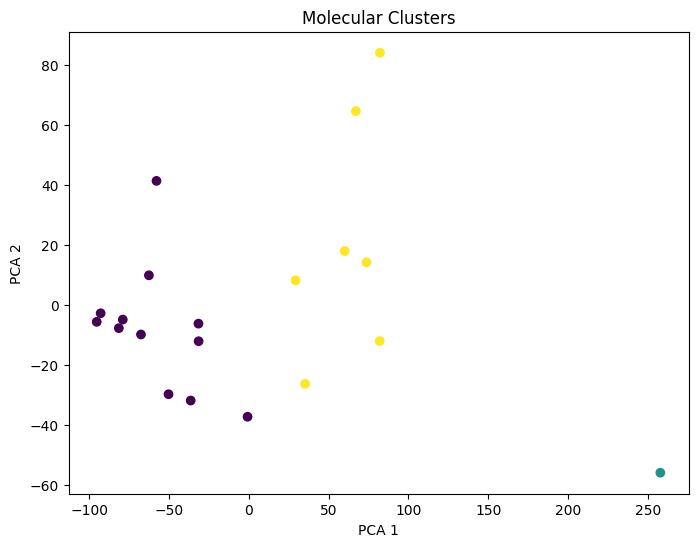

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=df["Cluster"])

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Molecular Clusters")

plt.show()

In [15]:
print(df["Cluster"].value_counts())

Cluster
0    12
2     7
1     1
Name: count, dtype: int64


In [16]:
print(df[["Name","Cluster"]])

            Name  Cluster
0        Aspirin        2
1       Caffeine        2
2      Ibuprofen        2
3    Paracetamol        2
4        Benzene        0
5        Toluene        0
6         Phenol        0
7        Acetone        0
8        Ethanol        0
9       Methanol        0
10       Glucose        2
11   Acetic acid        0
12   Citric acid        2
13      Nicotine        2
14   Cholesterol        1
15          Urea        0
16       Aniline        0
17   Naphthalene        0
18  Acetaldehyde        0
19  Formaldehyde        0
